# Experiment 4 – Pupillometry analysis

Code for the pupil results of *Goals shape human confidence* (Sepulveda, Fleming, Zurita & De Martino):

| Output | Section |
|---|---|
| Pupil differences by confidence, difficulty (\|ΔClicks\|) and accuracy reported in the Results | §5 |
| **Figure 7B** – pupil traces split by the number of chosen clicks, per frame | §6 |
| **Figure 7C** – time-resolved GLM (effect of chosen clicks) with FDR-corrected permutation test | §7 |

**Pipeline**
1. Load EyeLink sample report (100 Hz) and exclude pilot / low-accuracy participants.
2. Locate task events (first sound, choice, ITI, confidence) in every trial.
3. Remove blinks and saccades: linear interpolation of blinks, then regression of blink/saccade responses estimated by deconvolution (Knapen et al., 2016, *PLoS ONE*).
4. Z-score pupil and gaze position within trial; baseline-correct each trial with the 2 s preceding the first sound.
5. Merge with behaviour and split trials (confidence, |ΔClicks|, accuracy, chosen clicks).
6. At every sample of a ±2 s window around the choice, fit `pupil ~ chosen + unchosen + RT + gaze X + gaze Y` per participant and frame; compare the chosen-clicks coefficient between frames with a permutation test (FDR α = 0.01, ≥ 6 contiguous samples).

**Inputs** (in `../Data/DataPupil_Exp4/`): the EyeLink DataViewer sample report `eye_infoFull_report_fix_blink_100Hz.txt.xz` (xz-compressed; pandas reads it directly) and one behavioural file per participant, `pilot<N>/RESULTS_FILE.txt`.

**Frames:** `frame == 1` High Clicks (choose more clicks); `frame == 2` Low Clicks (choose fewer clicks).



## 0. Setup

In [9]:
import glob
import os
import sys
import warnings

import numpy as np
import pandas as pd
import scipy.signal
from scipy import stats
import statsmodels.formula.api as smf
import statsmodels.stats.multitest
import matplotlib.pyplot as plt
import seaborn as sns
from lmfit import minimize, Parameters

# FIR deconvolution package by T. Knapen (MIT licence), bundled in this folder
sys.path.append(os.path.join('FIRDeconvolution-master', 'src'))
import FIRDeconvolution

warnings.filterwarnings('ignore')
sns.set_style('white')
%matplotlib inline

In [10]:
# ---- Paths ----
DATA_DIR = os.path.join('..', 'Data', 'DataPupil_Exp4')
EYE_REPORT = os.path.join(DATA_DIR, 'eye_infoFull_report_fix_blink_100Hz.txt.xz')
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

# ---- Recording ----
SAMPLE_RATE = 100.0   # Hz (10 ms per sample)
N_PRACTICE_TRIALS = 20

# ---- Participant exclusion ----
PILOT_PARTICIPANTS = ['pilot1', 'pilot2', 'Pilot3']
LOW_ACCURACY_PARTICIPANTS = ['Pilot6', 'Pilot7', 'Pilot14', 'Pilot16', 'Pilot26', 'Pilot28']
REJECTED_PARTICIPANTS = PILOT_PARTICIPANTS + LOW_ACCURACY_PARTICIPANTS

# ---- Epochs (in samples) ----
BASELINE_SAMPLES = 200   # 2 s before the first sound
CHOICE_WINDOW = 200      # 2 s before and after the choice
CHOICE_EVENT = CHOICE_WINDOW

# ---- Permutation test ----
# RUN_PERMUTATIONS = True
# N_PERMUTATIONS = 50
# FDR_ALPHA = 0.01
# CLUSTER_SIZE = 6         # contiguous significant samples (60 ms)
# RANDOM_SEED = 2021
# PERM_RESULTS_FILE = os.path.join(RESULTS_DIR, 'Permutation_GroupRegression_Results_50perms.csv')

## 1. Helper functions

In [11]:
def z_score1(data_all, part_def, z_score_var):
    # Z-score a column within each participant; returns a list in row order
    z_matrix = []
    for i in data_all[part_def].unique():
        x = pd.to_numeric(data_all.loc[data_all[part_def] == i, z_score_var])
        z_matrix.extend(((x - np.mean(x)) / np.std(x)).values)
    return z_matrix


def splitBy(data_exp1, Splits_headers, Splits_variables):
    # Median split of each variable within participant and frame (1 = top half, 0 = bottom half).
    # Rows are returned ordered by participant and trial index.
    Split_cols = []
    for h in range(len(Splits_variables)):
        median_matrix = []
        for i in np.unique(data_exp1['part']):
            median_matrix_aux = []
            for j in np.unique(data_exp1['frame']):
                Splitdata = data_exp1.loc[(data_exp1['part'] == i) & (data_exp1['frame'] == j)]
                SplitSort = Splitdata.loc[:, ['Trial_Index_', Splits_variables[h]]].values
                SplitSort = SplitSort[np.argsort(SplitSort[:, 1])]

                lenPart = len(Splitdata)
                median_low = [0] * int(lenPart / 2)
                median_high = [1] * int(len(SplitSort) - len(median_low))

                # attach the split label and sort back to trial order
                median_aux = np.column_stack((SplitSort, median_low + median_high))
                SplitSorted = median_aux[np.argsort(median_aux[:, 0])]

                for kk in range(len(SplitSorted)):
                    if len(median_matrix_aux) == 0:
                        median_matrix_aux = SplitSorted[0]
                    else:
                        median_matrix_aux = np.vstack([median_matrix_aux, SplitSorted[kk]])

            # sort both frames by trial index and keep the split label only
            median_matrix_aux = median_matrix_aux[np.argsort(median_matrix_aux[:, 0])]
            median_matrix.extend(median_matrix_aux[:, 2])

        median_matrix = pd.DataFrame(median_matrix, columns=[Splits_headers[h]])
        Split_cols = median_matrix if h == 0 else pd.concat([Split_cols, median_matrix], axis=1)
    return Split_cols


def baseline_correct(pupilBase, baseP, trial_idx):
    # Subtract each trial's baseline pupil from its epoch; returns trials x samples
    return np.asarray([np.asarray(pupilBase[j], dtype=float) - baseP[j] for j in trial_idx])


def column(matrix, i):
    # i-th sample of every trial
    return [row[i] for row in matrix]


def set_time_ticks(event_time, n_samples, sample_factor=10):
    # Label x-axis in ms relative to the event (sample_factor = ms per sample)
    plt.xticks([0, event_time / 2, event_time, event_time * 3 / 2, n_samples],
               [int(-event_time * sample_factor), int(-event_time / 2 * sample_factor), 0,
                int(event_time / 2 * sample_factor), int((n_samples - event_time) * sample_factor)],
               fontsize=15)

## 2. Load eye-tracking data

In [12]:
pupilInfo = pd.read_csv(EYE_REPORT, sep='\t')

# Exclude pilot and low-accuracy participants
pupilInfo = pupilInfo.loc[~pupilInfo['RECORDING_SESSION_LABEL'].isin(REJECTED_PARTICIPANTS)]

# Participants were recorded from either the left or the right eye: merge both into one column
# (missing samples are coded '.' by DataViewer)
def merge_eyes(df, right, left):
    return pd.to_numeric(df[right].replace('.', 0)) + pd.to_numeric(df[left].replace('.', 0))

pupilInfo['pupilSizeAll'] = merge_eyes(pupilInfo, 'RIGHT_PUPIL_SIZE', 'LEFT_PUPIL_SIZE')
pupilInfo['saccAll'] = merge_eyes(pupilInfo, 'RIGHT_IN_SACCADE', 'LEFT_IN_SACCADE')
pupilInfo['gazeXAll'] = merge_eyes(pupilInfo, 'RIGHT_GAZE_X', 'LEFT_GAZE_X')
pupilInfo['gazeYAll'] = merge_eyes(pupilInfo, 'RIGHT_GAZE_Y', 'LEFT_GAZE_Y')
pupilInfo = pupilInfo.drop(columns=['RIGHT_PUPIL_SIZE', 'LEFT_PUPIL_SIZE', 'RIGHT_IN_SACCADE', 'LEFT_IN_SACCADE',
                                    'RIGHT_GAZE_X', 'LEFT_GAZE_X', 'RIGHT_GAZE_Y', 'LEFT_GAZE_Y'])

pupilInfo = pupilInfo.sort_values(by=['RECORDING_SESSION_LABEL', 'TRIAL_INDEX', 'TIMESTAMP'])

# Remove practice trials
pupilInfo = pupilInfo.loc[pupilInfo['TRIAL_INDEX'] > N_PRACTICE_TRIALS].reset_index(drop=True)

# Squared distance of gaze from the screen centre (512, 384; resolution 1024 x 768)
pupilInfo['devIdx'] = (512 - pupilInfo['gazeXAll'])**2 + (384 - pupilInfo['gazeYAll'])**2

print('Participants:', pupilInfo.RECORDING_SESSION_LABEL.nunique())

Participants: 32


### Task events
Row index (= sample position in `pupilInfo`) of the first sound, choice feedback, ITI, confidence screen and confidence acceptance in each trial. Trials missing any event are skipped.

In [5]:
indexDF = []
for i in pupilInfo.RECORDING_SESSION_LABEL.unique():
    pupilInfoPart = pupilInfo.loc[pupilInfo['RECORDING_SESSION_LABEL'] == i]
    for j in pupilInfoPart.TRIAL_INDEX.unique():
        trial = pupilInfoPart.loc[pupilInfoPart['TRIAL_INDEX'] == j]
        msg = trial['SAMPLE_MESSAGE']

        firstSndDF = trial.loc[msg.str.contains('FIRST_SOUND_R')]
        choiceDF = trial.loc[msg.str.contains('DISPLAY_FEEDBACK_R') | msg.str.contains('DISPLAY_FEEDBACK_L')]
        itiDF = trial.loc[msg.str.contains('ITI_APPEAR')]
        sliderAcceptDF = trial.loc[msg.str.contains('SLIDER_KEYB_ACCEPT')]
        confBeginDF = trial.loc[msg.str.contains('DISPLAY_BDM_CONF')]

        if firstSndDF.empty | choiceDF.empty | itiDF.empty | sliderAcceptDF.empty | confBeginDF.empty:
            continue

        indexDF.append([i, j,
                        int(firstSndDF.index.values[0]),
                        int(choiceDF.index.values[0]),
                        int(itiDF.index.values[0]),
                        int(sliderAcceptDF.index.values[0]),
                        int(confBeginDF.index.values[0])])

indexDF = pd.DataFrame(indexDF, columns=['part', 'trial', 'firstSndIdx', 'choiceIdx', 'itiIdx',
                                         'confAcceptIdx', 'confBeginIdx'])

## 3. Blink and saccade correction

Adapted from Knapen et al. (2016), *PLoS ONE* 11, e0155574, and the example in `FIRDeconvolution-master/test/pupil_preprocess_python.ipynb`. For each participant:
1. Linearly interpolate blinks (pupil = 0) with a 100 ms margin.
2. Low-pass (10 Hz) and band-pass (0.01–10 Hz) filter (3rd-order Butterworth).
3. Estimate blink and saccade responses by FIR deconvolution and fit them with pupil impulse-response functions.
4. Regress the fitted responses out of the band-passed signal and add back the slow (< 0.01 Hz) component.

In [6]:
MARGIN = int((100 * SAMPLE_RATE) / 1000)  # 100 ms, in samples
HP_FREQ = 0.01
LP_FREQ = 10.0
DOWNSAMPLE_RATE = 100
IRF_INTERVAL = 6  # s


def single_pupil_IRF(params, x):
    s1, n1, tmax1 = params['s1'], params['n1'], params['tmax1']
    return s1 * ((x**n1) * (np.e**((-n1 * x) / tmax1)))


def single_pupil_IRF_ls(params, x, data):
    return single_pupil_IRF(params, x) - data


def double_pupil_IRF(params, x):
    s1, s2 = params['s1'], params['s2']
    n1, n2 = params['n1'], params['n2']
    tmax1, tmax2 = params['tmax1'], params['tmax2']
    return s1 * ((x**n1) * (np.e**((-n1 * x) / tmax1))) + s2 * ((x**n2) * (np.e**((-n2 * x) / tmax2)))


def double_pupil_IRF_ls(params, x, data):
    return double_pupil_IRF(params, x) - data


def event_onsets_offsets(is_event, is_clear, timepoints):
    # Start and end timestamps of events (is_event: sample inside the event; is_clear: sample outside it)
    starts, ends = [], []
    for kk in range(len(is_event) - 1):
        if is_event[kk] and kk == 0:
            starts.append(timepoints[kk])
        if is_event[kk + 1] and (kk + 1 == len(is_event) - 1):
            ends.append(timepoints[kk])
        if is_clear[kk] and is_event[kk + 1]:
            starts.append(timepoints[kk + 1])
        if is_event[kk] and is_clear[kk + 1]:
            ends.append(timepoints[kk])
    return np.array(starts), np.array(ends)


def clean_participant_pupil(df):
    timepoints = df.TIMESTAMP.values - df.TIMESTAMP.values[0]
    pupil = df.pupilSizeAll.values

    sac = df.saccAll.values
    sac_starts, _ = event_onsets_offsets(sac == 1, sac == 0, timepoints)
    sac_ends = sac_starts  # as in the original analysis
    blink_starts, blink_ends = event_onsets_offsets(pupil == 0, pupil > 0, timepoints)

    # 1. Interpolate blinks
    pupil_interpolated = np.array(pupil.copy())
    for b in range(blink_starts.shape[0]):
        blink_start = max(np.where(timepoints == blink_starts[b])[0][0] - MARGIN + 1, 0)
        blink_end = min(np.where(timepoints == blink_ends[b])[0][0] + MARGIN + 1, len(pupil_interpolated) - 1)
        pupil_interpolated[blink_start:blink_end] = np.linspace(pupil_interpolated[blink_start],
                                                                pupil_interpolated[blink_end],
                                                                blink_end - blink_start, endpoint=False)

    # 2. Filter
    bhp, ahp = scipy.signal.butter(3, HP_FREQ / (SAMPLE_RATE / 2), btype='high')
    blp, alp = scipy.signal.butter(3, LP_FREQ / (SAMPLE_RATE / 2))
    pupil_interpolated_hp = scipy.signal.filtfilt(bhp, ahp, pupil_interpolated)
    pupil_interpolated_lp = scipy.signal.filtfilt(blp, alp, pupil_interpolated)
    pupil_interpolated_bp = scipy.signal.filtfilt(blp, alp, pupil_interpolated_hp)

    # 3. Deconvolve blink and saccade responses
    new_sample_rate = SAMPLE_RATE / DOWNSAMPLE_RATE
    fir = FIRDeconvolution.FIRDeconvolution(
        signal=scipy.signal.decimate(pupil_interpolated_bp, DOWNSAMPLE_RATE, 1),
        events=[blink_ends / SAMPLE_RATE, sac_ends / SAMPLE_RATE], event_names=['blinks', 'sacs'],
        sample_frequency=new_sample_rate, deconvolution_frequency=new_sample_rate,
        deconvolution_interval=[0, IRF_INTERVAL])
    fir.create_design_matrix()
    fir.regress()
    fir.betas_for_events()
    blink_response = np.array(fir.betas_per_event_type[0]).ravel()
    sac_response = np.array(fir.betas_per_event_type[1]).ravel()
    blink_response = blink_response - blink_response[0].mean()
    sac_response = sac_response - blink_response[0].mean()

    # fit impulse-response functions to the deconvolved responses
    x = np.linspace(0, IRF_INTERVAL, len(blink_response))
    params = Parameters()
    params.add('s1', value=-1, min=-np.inf, max=-1e-25)
    params.add('s2', value=1, min=1e-25, max=np.inf)
    params.add('n1', value=10, min=9, max=11)
    params.add('n2', value=10, min=8, max=12)
    params.add('tmax1', value=0.9, min=0.5, max=1.5)
    params.add('tmax2', value=2.5, min=1.5, max=4)
    blink_result = minimize(double_pupil_IRF_ls, params, method='powell', args=(x, blink_response))
    sac_result = minimize(single_pupil_IRF_ls, params, method='powell', args=(x, sac_response))

    # 4. Regress fitted responses out of the band-passed signal (kernels at full sampling rate)
    x = np.linspace(0, IRF_INTERVAL, int(IRF_INTERVAL * SAMPLE_RATE))
    blink_kernel = double_pupil_IRF(blink_result.params, x)
    sac_kernel = double_pupil_IRF(sac_result.params, x)

    blink_end_idx = [np.where(timepoints == t)[0][0] for t in blink_ends]
    blink_reg = np.zeros(len(pupil))
    blink_reg[blink_end_idx] = 1
    sac_reg = np.zeros(len(pupil))
    sac_reg[blink_end_idx] = 1  # as in the original analysis
    regs = [scipy.signal.fftconvolve(blink_reg, blink_kernel, 'full')[:-(len(blink_kernel) - 1)],
            scipy.signal.fftconvolve(sac_reg, sac_kernel, 'full')[:-(len(sac_kernel) - 1)]]

    design_matrix = np.matrix(np.vstack(regs)).T
    betas = np.array(((design_matrix.T * design_matrix).I * design_matrix.T) * np.matrix(pupil_interpolated_bp).T).ravel()
    explained = np.sum(np.vstack([betas[i] * regs[i] for i in range(len(betas))]), axis=0)

    pupil_clean_bp = pupil_interpolated_bp - explained
    return pupil_clean_bp + (pupil_interpolated_lp - pupil_interpolated_bp)


pupil_clean_all = []
for i in pupilInfo.RECORDING_SESSION_LABEL.unique():
    print('Cleaning participant', i)
    pupil_clean_all = np.append(pupil_clean_all,
                                clean_participant_pupil(pupilInfo.loc[pupilInfo['RECORDING_SESSION_LABEL'] == i]))

pupilInfo['pupilSizeBlinkInterp'] = pupil_clean_all

Cleaning participant P33x2
Cleaning participant Pilot10
Cleaning participant Pilot11
Cleaning participant Pilot12
Cleaning participant Pilot13
Cleaning participant Pilot15
Cleaning participant Pilot17
Cleaning participant Pilot18
Cleaning participant Pilot19
Cleaning participant Pilot20
Cleaning participant Pilot21
Cleaning participant Pilot22
Cleaning participant Pilot23
Cleaning participant Pilot24
Cleaning participant Pilot25
Cleaning participant Pilot27
Cleaning participant Pilot29
Cleaning participant Pilot30
Cleaning participant Pilot31
Cleaning participant Pilot32
Cleaning participant Pilot34
Cleaning participant Pilot35
Cleaning participant Pilot36
Cleaning participant Pilot37
Cleaning participant Pilot38
Cleaning participant Pilot39
Cleaning participant Pilot4
Cleaning participant Pilot40
Cleaning participant Pilot41
Cleaning participant Pilot5
Cleaning participant Pilot8
Cleaning participant Pilot9


## 4. Trial-wise normalisation and epochs

Pupil size and gaze position are z-scored within each trial. Epochs are baseline-corrected with the mean z-scored pupil in the 2 s before the first sound.

In [7]:
zPupil, zXposTrial, zYposTrial = [], [], []

for i in pupilInfo.RECORDING_SESSION_LABEL.unique():
    pupilInfoPart = pupilInfo.loc[pupilInfo['RECORDING_SESSION_LABEL'] == i]
    for j in pupilInfoPart.TRIAL_INDEX.unique():
        trial = pupilInfoPart.loc[pupilInfoPart['TRIAL_INDEX'] == j]

        pupilTrial = trial.pupilSizeBlinkInterp.values
        zPupil.extend((pupilTrial - np.nanmean(pupilTrial)) / np.nanstd(pupilTrial))

        # gaze X is scaled by the SD of the deviation index, as in the original analysis
        XIdxTrial = trial.gazeXAll.values
        zXposTrial.extend((XIdxTrial - np.nanmean(XIdxTrial)) / np.nanstd(trial.devIdx.values))
        YIdxTrial = trial.gazeYAll.values
        zYposTrial.extend((YIdxTrial - np.nanmean(YIdxTrial)) / np.nanstd(YIdxTrial))

pupilInfo['zPupil'] = zPupil
pupilInfo['zX'] = zXposTrial
pupilInfo['zY'] = zYposTrial

### Behavioural data

In [8]:

# Behavioural files: ../Data/DataPupil_Exp4/pilot<N>/RESULTS_FILE.txt
DATA_DIR_BEH = DATA_DIR

# Participant numbers from the EyeLink session labels (e.g. 'Pilot12' -> 12)
numPartRecover = []
for label in pupilInfo.RECORDING_SESSION_LABEL.unique():
    numPartRecover.append(int(label.replace('Pilot', '').replace('pilot', '').replace('P', '').replace('x2', '')))

choiceNameFrames = []
for n in numPartRecover:
    choiceNameFrames.extend(sorted(glob.glob(os.path.join(DATA_DIR_BEH, 'pilot' + str(n), 'RESULTS_FILE.txt'))))

choiceFrameAll = pd.DataFrame()
for j, fname in enumerate(choiceNameFrames):
    choiceFrames = pd.read_csv(fname, sep=r'\s+')
    choiceFrames['part'] = j
    choiceFrameAll = pd.concat([choiceFrameAll, choiceFrames], ignore_index=True)

# Choice: 1 = right ('m' key), 0 = left ('z' key); freql / freqr = number of clicks left / right
choiceFrameAll['Choice'] = (choiceFrameAll['Choice_SND1'] == 'm') * 1
choiceFrameAll['absDFreq'] = np.abs(choiceFrameAll['freqr'] - choiceFrameAll['freql'])
choiceFrameAll['choFreq'] = ((choiceFrameAll['Choice'] == 0) * choiceFrameAll['freql'] +
                             (choiceFrameAll['Choice'] == 1) * choiceFrameAll['freqr'])
choiceFrameAll['unchoFreq'] = ((choiceFrameAll['Choice'] == 1) * choiceFrameAll['freql'] +
                               (choiceFrameAll['Choice'] == 0) * choiceFrameAll['freqr'])

# Z-score within participant
for new, old in [('zRT', 'Choice_SND1_RT'), ('zConf', 'CONF'), ('zLFreq', 'freql'), ('zRFreq', 'freqr'),
                 ('zAbsDFreq', 'absDFreq'), ('zChoFreq', 'choFreq'), ('zUnchoFreq', 'unchoFreq')]:
    choiceFrameAll[new] = z_score1(choiceFrameAll, 'part', old)

# Median splits within participant and frame
for split, var in [('ConfSplit', 'zConf'), ('DFreqSplit', 'zAbsDFreq'), ('ChoFreqSplit', 'zChoFreq')]:
    choiceFrameAll[split] = splitBy(choiceFrameAll, Splits_headers=[split], Splits_variables=[var])[split].values

# Accuracy: frame 1 (High Clicks) = chose the side with more clicks; frame 2 (Low Clicks) = fewer clicks
left_fewer = choiceFrameAll.zLFreq <= choiceFrameAll.zRFreq
left_more = choiceFrameAll.zLFreq >= choiceFrameAll.zRFreq
correct_high = ((choiceFrameAll.Choice == 1) & left_fewer) | ((choiceFrameAll.Choice == 0) & left_more)
correct_low = ((choiceFrameAll.Choice == 0) & left_fewer) | ((choiceFrameAll.Choice == 1) & left_more)
choiceFrameAll['correct'] = np.where(choiceFrameAll.frame == 1, correct_high, correct_low).astype(int)

In [9]:
# Event indices for the participants with behavioural data, in the same order as choiceFrameAll
pupiIdxBehav = pd.concat([indexDF.loc[indexDF['part'] == j] for j in choiceFrameAll.Session_Name_.unique()],
                         ignore_index=True)

# Baseline: mean pupil in the 2 s before the first sound
basePBehav = [np.nanmean(pupilInfo.iloc[i - BASELINE_SAMPLES:i - 1].zPupil.values.astype(float))
              for i in pupiIdxBehav['firstSndIdx'].values.astype(int)]

# Epochs of +/- 2 s around the choice: pupil and gaze position
choice_idx = pupiIdxBehav['choiceIdx'].values.astype(int)
pupilChoice = [pupilInfo.iloc[i - CHOICE_WINDOW:i + CHOICE_WINDOW].zPupil.values for i in choice_idx]
pupilChoice_X = [pupilInfo.iloc[i - CHOICE_WINDOW:i + CHOICE_WINDOW].zX.values for i in choice_idx]
pupilChoice_Y = [pupilInfo.iloc[i - CHOICE_WINDOW:i + CHOICE_WINDOW].zY.values for i in choice_idx]

assert len(pupilChoice) == len(choiceFrameAll), 'pupil and behavioural trials do not match'

## 5. Pupil at decision time by confidence, difficulty and accuracy

Trials pooled across frames. The printed values (mean relative pupil area over the ±2 s choice window, averaged within participant, and paired t-test) are those reported in the Results.

In [10]:
def show_raw_pupil_split(pupilBase, event_time, choiceFrameAll, baseP, splitVar, title='', labFrame=('High', 'Low')):
    data_expHigh = choiceFrameAll.loc[choiceFrameAll[splitVar] == 1]
    data_expLow = choiceFrameAll.loc[choiceFrameAll[splitVar] == 0]

    # Average trace across all trials
    base1 = baseline_correct(pupilBase, baseP, data_expHigh.index.values)
    base2 = baseline_correct(pupilBase, baseP, data_expLow.index.values)

    plt.figure(figsize=(6, 5))
    colorP = ['#5BC8AF', '#F9CB40']
    xSecs = np.arange(base1.shape[1])
    for base, color, label in [(base1, colorP[0], labFrame[0]), (base2, colorP[1], labFrame[1])]:
        plt.errorbar(xSecs, np.nanmean(base, axis=0), yerr=stats.sem(base, axis=0, nan_policy='omit'),
                     color=color, marker='', alpha=0.05)
        plt.plot(xSecs, np.nanmean(base, axis=0), color=color, label=label, ls='-')
    plt.axvline(event_time, color='black', lw=2, alpha=0.5, ls='--')
    plt.title(title, size=18)
    plt.xlabel('Time Samples [ms]', size=18)
    plt.ylabel('Relative Pupil Area', size=18)
    set_time_ticks(event_time, len(xSecs))
    plt.yticks(fontsize=15)
    plt.legend(frameon=False, fontsize=15)
    sns.despine()

    # Participant means over the whole window, compared with a paired t-test
    meanHigh, meanLow = [], []
    for i in choiceFrameAll['part'].unique():
        meanHigh.append(np.nanmean(baseline_correct(pupilBase, baseP,
                        data_expHigh.loc[data_expHigh['part'] == i].index.values), axis=0))
        meanLow.append(np.nanmean(baseline_correct(pupilBase, baseP,
                       data_expLow.loc[data_expLow['part'] == i].index.values), axis=0))
    PreDec1 = np.mean(meanHigh, axis=1)
    PreDec2 = np.mean(meanLow, axis=1)

    print('participant number: ' + str(len(PreDec1)))
    print('Pupil Average High: ' + str(np.mean(PreDec1)) + '; std error: ' + str(np.std(PreDec1) / np.sqrt(len(PreDec2))))
    print('Pupil Average Low: ' + str(np.mean(PreDec2)) + '; std error: ' + str(np.std(PreDec2) / np.sqrt(len(PreDec2))))
    print('t-test pupilHigh vs pupilLow (Overall time): ' + str(stats.ttest_rel(PreDec1, PreDec2)))

participant number: 32
Pupil Average High: 0.7861147349156371; std error: 0.06650418336638357
Pupil Average Low: 0.8726126503098008; std error: 0.07814794911656249
t-test pupilHigh vs pupilLow (Overall time): TtestResult(statistic=-3.105521939969388, pvalue=0.004040076283185335, df=31)


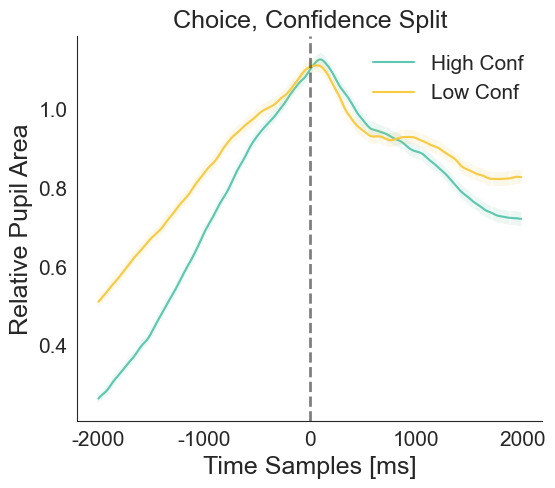

In [11]:
show_raw_pupil_split(pupilChoice, CHOICE_EVENT, choiceFrameAll, basePBehav, 'ConfSplit',
                     title='Choice, Confidence Split', labFrame=['High Conf', 'Low Conf'])

participant number: 32
Pupil Average High: 0.8009246404550805; std error: 0.06969993917512203
Pupil Average Low: 0.8578330502508108; std error: 0.07473824715026442
t-test pupilHigh vs pupilLow (Overall time): TtestResult(statistic=-2.3290292809488493, pvalue=0.026549054264524738, df=31)


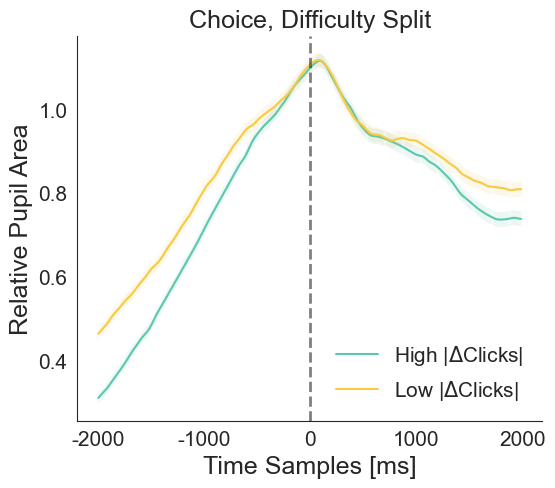

In [12]:
show_raw_pupil_split(pupilChoice, CHOICE_EVENT, choiceFrameAll, basePBehav, 'DFreqSplit',
                     title='Choice, Difficulty Split', labFrame=[r'High |$\Delta$Clicks|', r'Low |$\Delta$Clicks|'])

participant number: 32
Pupil Average High: 0.8131124822442447; std error: 0.06807929298276269
Pupil Average Low: 0.9094047928105352; std error: 0.08788853839335267
t-test pupilHigh vs pupilLow (Overall time): TtestResult(statistic=-3.205141792856837, pvalue=0.0031228232296262215, df=31)


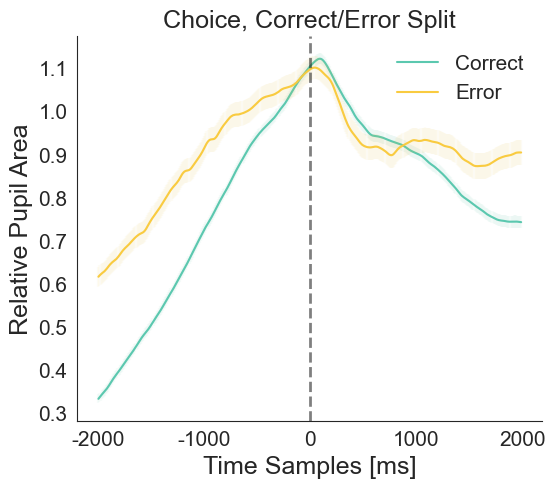

In [13]:
show_raw_pupil_split(pupilChoice, CHOICE_EVENT, choiceFrameAll, basePBehav, 'correct',
                     title='Choice, Correct/Error Split', labFrame=['Correct', 'Error'])

## 6. Figure 7B – pupil by number of chosen clicks, per frame
Median split of chosen clicks within participant and frame. Lines: mean across all trials; shading: SEM.

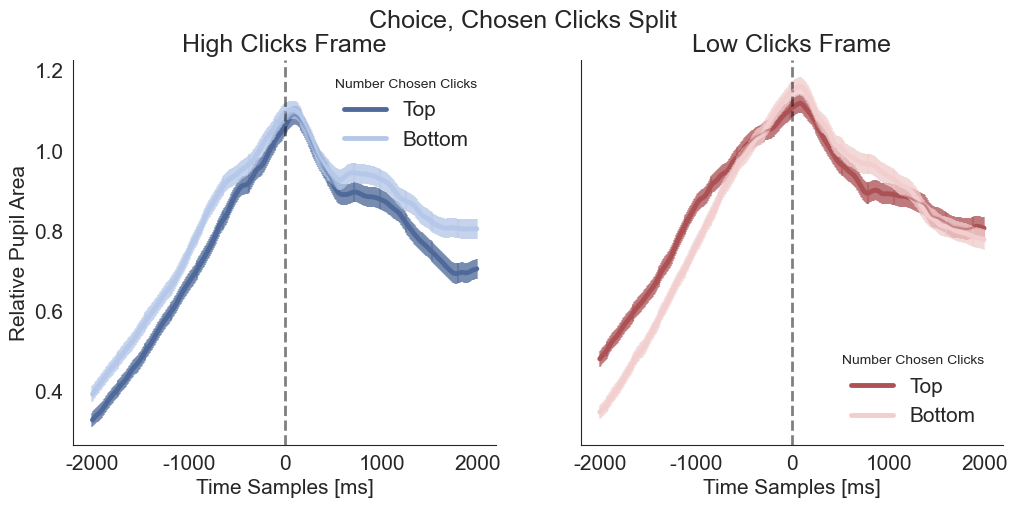

In [14]:
def show_frame_pupil_split(pupilBase, event_time, choiceFrameAll, baseP, splitVar, title='',
                           labFrame=('High', 'Low'), titleLeg=''):
    colorP = ['#4F6A9A', '#AC5255', '#B5C8E9', '#F2CECF']
    fig, axes = plt.subplots(1, 2, sharey=True, figsize=(12, 5))

    for ax, frame, (c_top, c_bottom), frame_title in [(axes[0], 1, (colorP[0], colorP[2]), 'High Clicks Frame'),
                                                       (axes[1], 2, (colorP[1], colorP[3]), 'Low Clicks Frame')]:
        data_frame = choiceFrameAll.loc[choiceFrameAll['frame'] == frame]
        base1 = baseline_correct(pupilBase, baseP, data_frame.loc[data_frame[splitVar] == 1].index.values)
        base2 = baseline_correct(pupilBase, baseP, data_frame.loc[data_frame[splitVar] == 0].index.values)

        xSecs = np.arange(base1.shape[1])
        for base, color, label in [(base1, c_top, labFrame[0]), (base2, c_bottom, labFrame[1])]:
            ax.errorbar(xSecs, np.nanmean(base, axis=0), yerr=stats.sem(base, axis=0, nan_policy='omit'),
                        color=color, marker='', alpha=0.5)
            ax.plot(xSecs, np.nanmean(base, axis=0), color=color, label=label, ls='-', linewidth=3.5)
        ax.axvline(event_time, color='black', lw=2, alpha=0.5, ls='--')

        plt.sca(ax)
        set_time_ticks(event_time, len(xSecs))
        plt.yticks(fontsize=15)
        ax.set_xlabel('Time Samples [ms]', fontsize=15)
        ax.legend(frameon=False, fontsize=15, title=titleLeg)
        ax.set_title(frame_title, fontsize=18)

    axes[0].set_ylabel('Relative Pupil Area', fontsize=15)
    plt.suptitle(title, size=18)
    sns.despine()


show_frame_pupil_split(pupilChoice, CHOICE_EVENT, choiceFrameAll, basePBehav, 'ChoFreqSplit',
                       title='Choice, Chosen Clicks Split', labFrame=['Top', 'Bottom'], titleLeg='Number Chosen Clicks')

## 7. Figure 7C – time-resolved GLM and permutation test

At each sample of the ±2 s choice window, for each participant and frame:

`pupil ~ chosen clicks + unchosen clicks + RT + gaze X + gaze Y`

The group effect is the mean chosen-clicks coefficient across participants. The frame difference (High − Low) is tested against a null distribution built from `N_PERMUTATIONS` permuted datasets: in each permutation, every column of each participant's data is permuted independently within frame, the regressions are refitted and the group-mean difference is recomputed. P-values are FDR-corrected (Benjamini–Hochberg, α = 0.01) across samples, and only runs of `CLUSTER_SIZE` contiguous significant samples are reported.

In [15]:
def column(matrix, i):
    return [row[i] for row in matrix]

In [16]:
def shuffle(df, n=1, axis=0):     
         df = df.copy()
         for _ in range(n):
            df.apply(np.random.shuffle, axis=axis)
         return df

In [17]:
def shuffleDF (df1,df2):

    df1_shuff = pd.DataFrame(columns = df1.columns)
    df2_shuff = pd.DataFrame(columns = df2.columns)
    
    for ii in range(len(df1)):
        if rand(1)>0.5:
            df1_shuff.loc[df2.index[ii]] = df2.iloc[ii]
            df2_shuff.loc[df1.index[ii]] = df1.iloc[ii]
        else:
            df2_shuff.loc[df1.index[ii]] = df1.iloc[ii]
            df1_shuff.loc[df2.index[ii]] = df2.iloc[ii]
    
    return(df1_shuff,df2_shuff)


In [18]:
def shuffleDFone (df1,df2):#

    #df1_shuff = pd.DataFrame(columns = df1.columns)
    #df2_shuff = pd.DataFrame(columns = df2.columns)
    
    df1_shuff = shuffle(df1)
    df2_shuff = shuffle(df2)
    
    return(df1_shuff,df2_shuff)


In [19]:
def shuffleDFcol (df1,df2,column2shuffle):#

    #df1_shuff = pd.DataFrame(columns = df1.columns)
    #df2_shuff = pd.DataFrame(columns = df2.columns)
    
    df1[column2shuffle[0]] = np.random.permutation(df1[column2shuffle].values)
    df2[column2shuffle[0]] = np.random.permutation(df2[column2shuffle].values)

    return(df1,df2)


In [20]:
import statsmodels.formula.api as sm
import statsmodels
def show_frame_pupil_split_regressPartPerm(pupilBase,event_time,choiceFrameAll,baseP,pupilChoice_X,pupilChoice_Y, splitVar = 'ConfSplit', title = "", labFrame = ['High','Low'],nperm = 50):
    
    
    # check if the size (number of trials) of pupil info and baseline pupil is the same
    if len(pupilBase) != len(baseP):
        print('pupil baseline and pupil trials have not the same number of trials. Beware!')    
    if len(choiceFrameAll) != len(baseP):
        print('behaviour trials and pupil trials have not the same number of trials. Beware!')      
    
    
    # initialize figure
    
    plt.figure(figsize=(12, 5))
    
    #fig, (ax1, ax2) = plt.subplots(1, 1, sharey=True)
    
    
    choiceFrameAllH = choiceFrameAll.loc[(choiceFrameAll['frame'] == 1)] 
    choiceFrameAllL = choiceFrameAll.loc[(choiceFrameAll['frame'] == 2)] 

    index_high = choiceFrameAllH.index.values
    index_low = choiceFrameAllL.index.values

    
     # extract high
    base1 = [None]*len(index_high)
    idxx= 0 
    for j in index_high:
        pupilSeq1S = [None]*len(pupilBase[j])
        for jj in range(len(pupilBase[j])):
            if pupilBase[j][jj]=='':
                pupilSeq1S[jj]=np.nan
            else:
                pupilSeq1S[jj] = float(pupilBase[j][jj])
        base1[idxx] = pupilSeq1S - baseP[j]
        idxx=idxx+1
    base1 = np.asarray(base1)
    
 
    # extract low    
    base2 = [None]*len(index_low)
    idxx= 0 
    for j in index_low:
        pupilSeq1S = [None]*len(pupilBase[j])
        for jj in range(len(pupilBase[j])):
            if pupilBase[j][jj]=='':
                pupilSeq1S[jj]=np.nan
            else:
                pupilSeq1S[jj] = float(pupilBase[j][jj])
        base2[idxx] = pupilSeq1S - baseP[j]
        idxx=idxx+1
    base2 = np.asarray(base2)
    
    # extract pupil position for each frame
    
    pupilChoice_X_H = [pupilChoice_X[i] for i in index_high]
    pupilChoice_Y_H = [pupilChoice_Y[i] for i in index_high]

    pupilChoice_X_L = [pupilChoice_X[i] for i in index_low]
    pupilChoice_Y_L = [pupilChoice_Y[i] for i in index_low]    
    
    
    # run regression analysis for each sample
    
    
    regFormula = "pupil ~ choEv + unchoEv + rt + xpos + ypos"
    betasH = []
    betasL = []
    
    betasErrorH_lower = []
    betasErrorH_upper = []
    
    betasErrorL_lower = []
    betasErrorL_upper = []
    
    betasErrorH_ = []
    betasErrorL_ = []
    
#    pVal_perm = [99]*len(base1[0])
#    pValH_perm = [99]*len(base1[0])
#    pValL_perm = [99]*len(base1[0])
    pVal_perm = []
    pValH_perm = []
    pValL_perm = []

    
    # frame 1
    dfH = pd.DataFrame()
    dfH['choEv'] =  choiceFrameAllH.zChoFreq.values
    dfH['unchoEv'] =  choiceFrameAllH.zUnchoFreq.values
    dfH['part']  = choiceFrameAllH.part.values
    dfH['rt']  = choiceFrameAllH.zRT.values

    
    # frame 2
    dfL = pd.DataFrame()
    dfL['choEv'] =  choiceFrameAllL.zChoFreq.values
    dfL['unchoEv'] =  choiceFrameAllL.zUnchoFreq.values
    dfL['part']  = choiceFrameAllL.part.values    
    dfL['rt']  = choiceFrameAllL.zRT.values
   
    
    for s in range(int(np.round(len(base1[0])))): # extract for each number of sample
        
        # to subsample 
        if s%40:
           continue
        
        print(s)
        # frame 1
        dfH['pupil'] = column(base1,s)
        dfL['pupil'] = column(base2,s)
        
        dfH['xpos']  = column(pupilChoice_X_H,s)
        dfH['ypos']  = column(pupilChoice_Y_H,s)

        dfL['xpos']  = column(pupilChoice_X_L,s)
        dfL['ypos']  = column(pupilChoice_Y_L,s)        
        
        
        betasH_p = []
        betasL_p = []
        deltaBeta_p = []
        
        
        for part1 in dfH.part.unique():
            
            dfH_p = dfH.loc[dfH['part'] == part1 ]
            dfL_p = dfL.loc[dfL['part'] == part1 ]
        
        
            olsRegH = sm.ols(formula = regFormula, data=dfH_p).fit()
            betasH_p.append(olsRegH.params.values[1])
            #betasErrorH_lower.append(olsRegH.conf_int(alpha=0.05, cols=None)[0].values[1])
            #betasErrorH_upper.append(olsRegH.conf_int(alpha=0.05, cols=None)[1].values[1])
            #betasErrorH_.append(olsRegH.conf_int(alpha=0.05, cols=None)[1].values[1] - olsRegH.conf_int(alpha=0.05, cols=None)[0].values[1])
            
            # frame 2
          
            olsRegL = sm.ols(formula = regFormula, data=dfL_p).fit()
            betasL_p.append(olsRegL.params.values[1])
            #betasErrorL_lower.append(olsRegL.conf_int(alpha=0.05, cols=None)[0].values[1])
            #betasErrorL_upper.append(olsRegL.conf_int(alpha=0.05, cols=None)[1].values[1])
            #betasErrorL_.append(olsRegL.conf_int(alpha=0.05, cols=None)[1].values[1] - olsRegL.conf_int(alpha=0.05, cols=None)[0].values[1])
            
            
            # difference between betas to estimate the threshold for permutation comparison.
            deltaBeta_p.append(olsRegH.params.values[1] - olsRegL.params.values[1])
            
        
        betasH.append(np.mean(betasH_p))
        betasL.append(np.mean(betasL_p))
        
        betasErrorH_.append(np.std(betasH_p)/np.sqrt(np.size(betasH_p)))
        betasErrorL_.append(np.std(betasL_p)/np.sqrt(np.size(betasL_p)))        
        
        
        
        
        # run permutations at group level         
        deltaBetas_p_perm = []
        for p in range(0,nperm):
                deltaBetas_p_perPart = []
                for part1 in dfH.part.unique():
            
                    dfH_p = dfH.loc[dfH['part'] == part1 ]
                    dfL_p = dfL.loc[dfL['part'] == part1 ]
    
                    dfH_p = dfH_p.drop(columns=['part'])
                    dfL_p = dfL_p.drop(columns=['part'])

                     # shuffle the trials between groups (frames)
                    df1_shuff, df2_shuff = shuffleDFone(dfH_p.reset_index(drop = True),dfL_p.reset_index(drop = True))
                    
                    # calculate regression for permutation dataframe1
                    olsReg1_perm = sm.ols(formula = regFormula, data=df1_shuff).fit()
                    #betas1_perm.append(olsReg1_perm.params.values[1])
                    
                    # calculate regression for permutation dataframe2
                    olsReg2_perm = sm.ols(formula = regFormula, data=df2_shuff).fit()
                    #betas2_perm.append(olsReg2_perm.params.values[1])
                        
                    deltaBetas_p_perPart.append(olsReg1_perm.params.values[1] - olsReg2_perm.params.values[1])
        
                
                
                deltaBetas_p_perm.append(np.mean(deltaBetas_p_perPart))
    
        
        group_beta = np.mean(betasH_p) - np.mean(betasL_p)
        pVal_perm.append(len(np.where(np.abs(deltaBetas_p_perm) >= np.abs(group_beta))[0])/len(deltaBetas_p_perm)) # p_value of the permutation test

        
#        pVal_perm.append(stats.ttest_rel(betasH_p, betasL_p)[1]) # p_value of the diffenrece
        
    
    
    # plot betas from the regression

    
    colorP = ['#4F6A9A','#AC5255','#B5C8E9','#F2CECF']
    #labFrame = ['High','Low']
    xSecs = np.array(range(0,len(betasH)))
    
    #plot High
    plt.errorbar(xSecs,betasH, yerr= betasErrorH_, color=colorP[2],marker='', alpha = 0.5 );
    plt.plot(xSecs,betasH,color=colorP[0],label = labFrame[0],ls = '-',linewidth=3.5)
    #plot Low frame
    xSecs = np.array(range(0,len(betasL)))

    plt.errorbar(xSecs,betasL, yerr= betasErrorL_, color=colorP[3],marker='', alpha = 0.5 );
    plt.plot(xSecs,betasL,color=colorP[1],label = labFrame[1],ls = '-',linewidth=3.5)
    
    plt.axvline(event_time, color='black', lw=2, alpha=0.5,ls = '--')
    plt.axhline(0, color='black', lw=1, alpha =1 ,ls = '-')

    plt.xlabel("Time Samples [ms]", fontsize = 15)
    plt.ylabel("Beta weights [a.u.]", fontsize = 15)
    
    
    sample_factor = 10
    
    event_time = np.round(len(pVal_perm)/2)

    
    #plt.sca(ax1)    
    plt.xticks([0, event_time/2 ,event_time,event_time*3/2,len(xSecs)], [
        int(-event_time*sample_factor),int(-event_time/2*sample_factor) ,0, int(event_time/2*sample_factor),int((len(xSecs)-event_time)*sample_factor) ],fontsize= 15)
    plt.yticks(fontsize= 15)
    #ax1.yaxis.label.set_size(15)
    #ax1.xaxis.label.set_size(15)
   
    plt.legend(frameon=False, fontsize = 15)
    plt.title("Pupil Size Regression", fontsize = 18)
    
    
    # plot permutation p-values for the difference between groups
    clusterSize = 6

    
    # FDR correction 0.01 (instead of bonferroni)
    #print(pVal_perm)
    _,pVal_perm_FDR,_,_ = statsmodels.stats.multitest.multipletests(pVal_perm, alpha=0.01, method='fdr_bh', is_sorted=False, returnsorted=False)

    
    
    for ii in range(len(pVal_perm_FDR)):
    # count the number of significant value in the cluster, if over 6 then the cluster is significant 
        if ii >clusterSize:
            if np.sum(np.array(pVal_perm_FDR[ii-clusterSize:ii])<0.01) == clusterSize:
                plt.plot(xSecs[ii-clusterSize:ii], [np.max(betasL)+ np.max(betasErrorL_)+0.025]*clusterSize, color='black',linewidth=4,solid_capstyle = 'butt')

    
    print(pVal_perm_FDR)
    sns.set_style("white")
    sns.despine()
    
    return(pVal_perm,betasH,betasL,betasErrorH_,betasErrorL_)

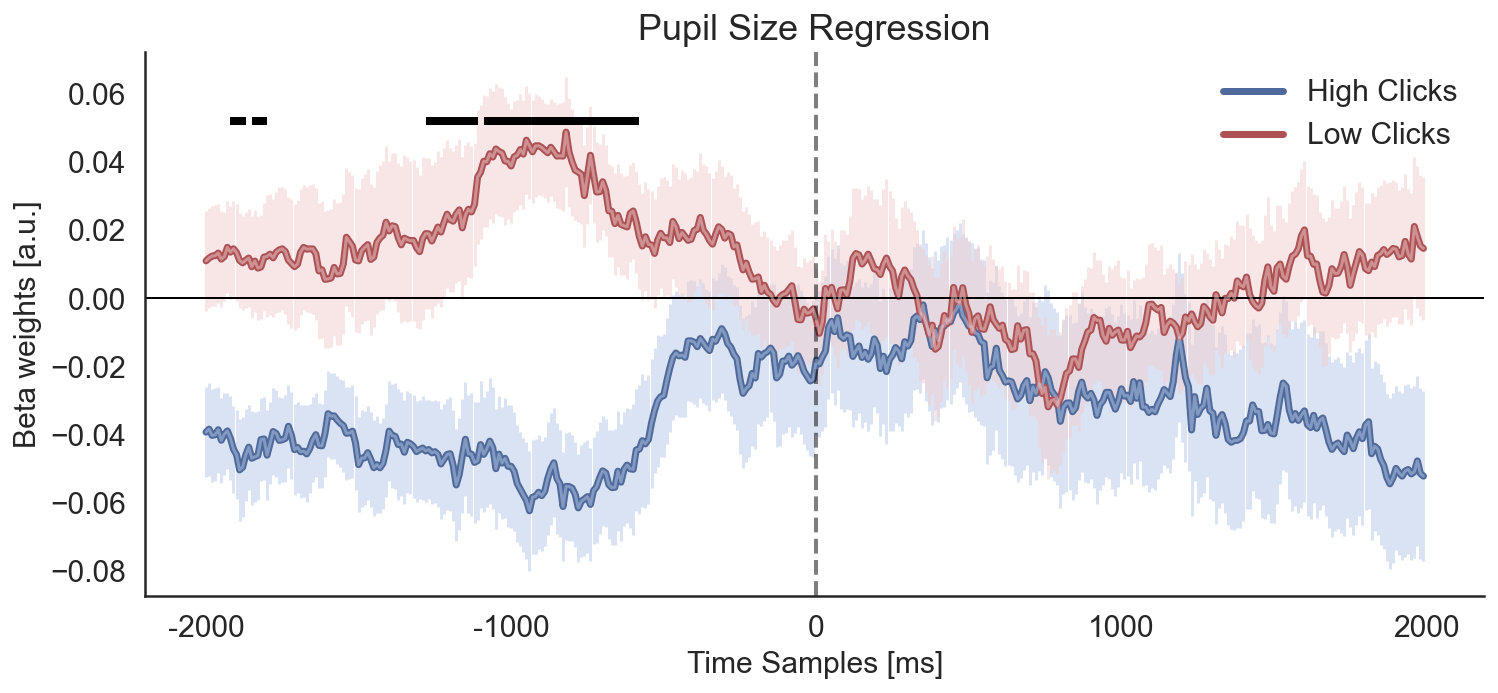

In [ ]:
pVal_perm0,betasH0,betasL0,betasErrorH_0,betasErrorL_0 = show_frame_pupil_split_regressPartPerm(pupilChoice,len(pupilChoice[1])/2,choiceFrameAll,basePBehav,pupilChoice_X,pupilChoice_Y,'ChoFreqSplit',title = 'Choice, Chosen Clicks Split', labFrame = ['High Chosen Clicks','Low Chosen Clicks'])

df_GROUPPERM_RESULTS = pd.DataFrame()
df_GROUPPERM_RESULTS['pVal'] = pVal_perm0
df_GROUPPERM_RESULTS['betasH'] = betasH0
df_GROUPPERM_RESULTS['betasL'] = betasL0
df_GROUPPERM_RESULTS['betasH_error'] = betasErrorH_0
df_GROUPPERM_RESULTS['betasL_error'] = betasErrorL_0
df_GROUPPERM_RESULTS.to_csv('Permutation_GroupRegression_Results_50perms.csv')  




labFrame = ['High Clicks', 'Low Clicks']
event_time = 200
colorP = ['#4F6A9A','#AC5255','#B5C8E9','#F2CECF']
#labFrame = ['High','Low']
xSecs = np.array(range(0,len(betasH0)))

#plot High
plt.errorbar(xSecs,betasH0, yerr= betasErrorH_0, color=colorP[2],marker='', alpha = 0.5 );
plt.plot(xSecs,betasH0,color=colorP[0],label = labFrame[0],ls = '-',linewidth=3.5)
#plot Low frame
xSecs = np.array(range(0,len(betasL0)))

plt.errorbar(xSecs,betasL0, yerr= betasErrorL_0, color=colorP[3],marker='', alpha = 0.5 );
plt.plot(xSecs,betasL0,color=colorP[1],label = labFrame[1],ls = '-',linewidth=3.5)

plt.axvline(event_time, color='black', lw=2, alpha=0.5,ls = '--')
plt.axhline(0, color='black', lw=1, alpha =1 ,ls = '-')

plt.xlabel("Time Samples [ms]", fontsize = 15)
plt.ylabel("Beta weights [a.u.]", fontsize = 15)


sample_factor = 10

event_time = np.round(len(pVal_perm0)/2)


#plt.sca(ax1)    
plt.xticks([0, event_time/2 ,event_time,event_time*3/2,len(xSecs)], [
    int(-event_time*sample_factor),int(-event_time/2*sample_factor) ,0, int(event_time/2*sample_factor),int((len(xSecs)-event_time)*sample_factor) ],fontsize= 15)
plt.yticks(fontsize= 15)
#ax1.yaxis.label.set_size(15)
#ax1.xaxis.label.set_size(15)

plt.legend(frameon=False, fontsize = 15)
plt.title("Pupil Size Regression", fontsize = 18)


# plot permutation p-values for the difference between groups
clusterSize = 6


# FDR correction 0.01 (instead of bonferroni)
#print(pVal_perm)
_,pVal_perm_FDR,_,_ = statsmodels.stats.multitest.multipletests(pVal_perm0, alpha=0.01, method='fdr_bh', is_sorted=False, returnsorted=False)


index_sig = []
for ii in range(len(pVal_perm_FDR)):
# count the number of significant value in the cluster, if over 6 then the cluster is significant 
    if ii >clusterSize:
        if np.sum(np.array(pVal_perm_FDR[ii-clusterSize:ii])<0.01) == clusterSize:
            plt.plot(xSecs[ii-clusterSize:ii], [np.max(betasL)+ np.max(betasErrorL_)+0.025]*clusterSize, color='black',linewidth=4,solid_capstyle = 'butt')
            index_sig.append(ii)

#print(pVal_perm_FDR)
sns.set_style("white")
sns.despine()



Mean coefficients over the significant time points (reported in the Results):

In [ ]:
print('Mean significant betas H frame: ' + str(np.mean(betasH0[index_sig])) + ' / std dev: ' + str(np.std(betasH0[index_sig])))
print('Mean significant betas L frame: ' + str(np.mean(betasL0[index_sig])) + ' / std dev: ' + str(np.std(betasL0[index_sig])))

Mean significant betas H frame: -0.052237825899072214 / std dev: 0.005454972148025211
Mean significant betas L frame: 0.03300258496583401/ std dev: 0.00973664748776902
